In [ ]:
# Instalacion de librerias
!pip install -q agentpy

import agentpy as ap
import numpy as np
import matplotlib.pyplot as plt
import IPython
from matplotlib.animation import FuncAnimation

print("Entorno listo")

Entorno listo


In [ ]:
# Configuracion de parametros y geometria
parameters = {
    'size': 120,
    'space_size': 140,
    'street_width': 6.4,
    'steps': 1000,
    'seed': 99,
    'prob': 0.13,
    'safe_distance': 3.0
}

C1  = np.array([30.0,  50.0])
C2  = np.array([76.0,  84.0])
PFA = np.array([116.0, 84.0])
C3  = C2 + (PFA - C2) * 0.5

R_ROTONDA = 9.0
SIZE      = parameters['size']
CARRIL    = 2.5

V_VERDE = (C2 - C1) / np.linalg.norm(C2 - C1)
P_VERDE = np.array([V_VERDE[1], -V_VERDE[0]])

V_AZUL = (PFA - C2) / np.linalg.norm(PFA - C2)
P_AZUL = np.array([V_AZUL[1], -V_AZUL[0]])

PENDIENTE  = (C2[1] - C1[1]) / (C2[0] - C1[0])
P_PERP_VAL = -1.0 / PENDIENTE

_p_nar    = np.array([1.0, P_PERP_VAL])
V_NARANJA = _p_nar / np.linalg.norm(_p_nar)
if V_NARANJA[1] < 0: V_NARANJA = -V_NARANJA
P_NARANJA_DER = np.array([V_NARANJA[1], -V_NARANJA[0]])

V_GRIS_NS = np.array([V_VERDE[1], -V_VERDE[0]])
if V_GRIS_NS[1] > 0: V_GRIS_NS = -V_GRIS_NS
V_GRIS_SN = -V_GRIS_NS

t_y = (SIZE - C1[1]) / V_GRIS_SN[1]
t_x = (0 - C1[0])   / V_GRIS_SN[0]
t_norte = min(t_y, t_x) if t_x > 0 else t_y
GRIS_NORTE = C1 + V_GRIS_SN * t_norte

t_y_sur = (0 - C1[1])    / V_GRIS_NS[1]
t_x_sur = (SIZE - C1[0]) / V_GRIS_NS[0] if V_GRIS_NS[0] > 0 else float('inf')
t_sur   = min(t_y_sur, t_x_sur) if t_x_sur > 0 else t_y_sur
GRIS_SUR = C1 + V_GRIS_NS * t_sur

C2_SALE   = C2  + P_AZUL * CARRIL
C2_ENTRA  = C2  - P_AZUL * CARRIL
C3_SALE   = C3  + P_AZUL * CARRIL
C3_ENTRA  = C3  - P_AZUL * CARRIL
PFA_SALE  = PFA + P_AZUL * CARRIL
PFA_ENTRA = PFA - P_AZUL * CARRIL
AZUL_SPAWN_ENTRA = np.array([120.0, PFA_ENTRA[1]])

C1_VERDE_SALE  = C1 + P_VERDE * CARRIL
C1_VERDE_ENTRA = C1 - P_VERDE * CARRIL
C2_VERDE_SALE  = C2 + P_VERDE * CARRIL
C2_VERDE_ENTRA = C2 - P_VERDE * CARRIL

y_borde_izq       = C1[1] - PENDIENTE * C1[0]
GRIS_CENTRO_BORDE = np.array([0.0, y_borde_izq])
VERDE_BORDE_SALE  = GRIS_CENTRO_BORDE + P_VERDE * CARRIL * 1.0
VERDE_BORDE_ENTRA = GRIS_CENTRO_BORDE - P_VERDE * CARRIL * 1.0
VERDE_SPAWN_SALE  = VERDE_BORDE_SALE  - V_VERDE * 3
VERDE_SPAWN_ENTRA = VERDE_BORDE_ENTRA - V_VERDE * 3

_naranja_x_en_y0   = C2[0] - (C2[1] / P_PERP_VAL)
_naranja_x_en_yMAX = C2[0] + ((SIZE - C2[1]) / P_PERP_VAL)
if _naranja_x_en_y0 > SIZE:
    _naranja_y_xMAX = (SIZE - C2[0]) * P_PERP_VAL + C2[1]
    NAR_CENTRO_ORIGEN = np.array([float(SIZE), _naranja_y_xMAX])
else:
    NAR_CENTRO_ORIGEN = np.array([_naranja_x_en_y0, 0.0])
NAR_CENTRO_DESTINO = np.array([_naranja_x_en_yMAX, float(SIZE)])

NAR_ORIGEN_UNICO = NAR_CENTRO_ORIGEN.copy()
NAR_DESTINO_SUBE = NAR_CENTRO_DESTINO + P_NARANJA_DER * CARRIL
NAR_DESTINO_BAJA = NAR_CENTRO_DESTINO - P_NARANJA_DER * CARRIL
C2_NAR_SUBE      = C2 + P_NARANJA_DER * CARRIL
C2_NAR_BAJA      = C2 - P_NARANJA_DER * CARRIL

ROSA_X_ORIGEN = C3[0] + ((SIZE - C3[1]) / P_PERP_VAL)
ROSA_ORIGEN   = np.array([ROSA_X_ORIGEN, float(SIZE)])
V_ROSA        = (C3_SALE - ROSA_ORIGEN) / np.linalg.norm(C3_SALE - ROSA_ORIGEN)

# Carril sur→norte de Av. Eugenio Garza Sada
P_GRIS_SN_DER       = np.array([V_GRIS_NS[1], -V_GRIS_NS[0]]) * -1
GRIS_SPAWN_SUR      = GRIS_SUR  + V_GRIS_NS * 3 + P_GRIS_SN_DER * CARRIL
GRIS_NORTE_CARRIL   = GRIS_NORTE + P_GRIS_SN_DER * CARRIL
GRIS_SPAWN_NORTE_SN = GRIS_NORTE_CARRIL + V_GRIS_SN * 3

# Carril norte→sur de Av. Eugenio Garza Sada (carril izquierdo)
r_car_sn             = R_ROTONDA - CARRIL
GRIS_NORTE_CARRIL_NS = GRIS_NORTE - P_GRIS_SN_DER * CARRIL
GRIS_SUR_CARRIL_NS   = GRIS_SUR   - P_GRIS_SN_DER * CARRIL
_pre_arco_ns_ref    = C1 + V_GRIS_SN * (r_car_sn + 2.0) - P_GRIS_SN_DER * CARRIL * 0.5
GRIS_SPAWN_NORTE_NS = _pre_arco_ns_ref + V_GRIS_SN * 40
GRIS_SPAWN_SUR_NS   = GRIS_SUR_CARRIL_NS + V_GRIS_NS * 3

DETECTION_RADIUS = 5.0

C3_SEM  = C3_SALE.copy()
C2_SEM  = C2_ENTRA.copy()
C2_SEM4 = C2_SALE.copy()

r_car_entra = R_ROTONDA + CARRIL
C1_SEM      = C1_VERDE_ENTRA + V_VERDE * (r_car_entra + 2.0)

C1_SEM_SN = C1 + V_GRIS_NS * (r_car_sn + 6.0) + P_GRIS_SN_DER * CARRIL

C1_SEM_S6 = C1_VERDE_SALE - V_VERDE * (r_car_entra + 2.0)

C_SEM_S7  = C3_SEM - P_AZUL * CARRIL * 2

C1_SEM_NS = C1 + V_GRIS_SN * (r_car_sn + 6.0) - P_GRIS_SN_DER * CARRIL * 0.5

C_SEM_S9 = C3_SALE - V_ROSA * 8

CYCLE      = 60
GREEN_MIN  = 8
GREEN_BASE = 25
GREEN_EXT  = 40

print("Geometría calculada:")
print(f"  VERDE_SPAWN_SALE       = {VERDE_SPAWN_SALE}")
print(f"  AZUL_SPAWN_ENTRA       = {AZUL_SPAWN_ENTRA}")
print(f"  GRIS_SPAWN_SUR         = {GRIS_SPAWN_SUR}")
print(f"  GRIS_NORTE_CARRIL      = {GRIS_NORTE_CARRIL}")
print(f"  GRIS_SPAWN_NORTE_NS    = {GRIS_SPAWN_NORTE_NS}")
print(f"  _pre_arco_ns_ref       = {_pre_arco_ns_ref}")
print(f"  GRIS_SUR_CARRIL_NS     = {GRIS_SUR_CARRIL_NS}")
print(f"  C1_SEM                 = {C1_SEM}")
print(f"  C1_SEM_SN              = {C1_SEM_SN}")
print(f"  C1_SEM_S6              = {C1_SEM_S6}")
print(f"  C_SEM_S7               = {C_SEM_S7}")
print(f"  C1_SEM_NS              = {C1_SEM_NS}")
print(f"  C_SEM_S9               = {C_SEM_S9}")

Geometría calculada:
  VERDE_SPAWN_SALE       = [-0.92655077 24.03247342]
  AZUL_SPAWN_ENTRA       = [120.   86.5]
  GRIS_SPAWN_SUR         = [70.75013528 -0.92655077]
  GRIS_NORTE_CARRIL      = [ 2.01044035 92.07421295]
  GRIS_SPAWN_NORTE_NS    = [ 0.16681336 88.25955403]
  _pre_arco_ns_ref       = [23.9424558  56.09250838]
  GRIS_SUR_CARRIL_NS     = [64.94608139 -1.48597765]
  C1_SEM                 = [39.37040026 60.03471968]
  C1_SEM_SN              = [39.44032862 41.43377588]
  C1_SEM_S6              = [20.62959974 39.96528032]
  C_SEM_S7               = [96.  86.5]
  C1_SEM_NS              = [21.56489156 59.30921294]
  C_SEM_S9               = [91.45153895 88.08114748]


In [ ]:
# Logica de semaforos y heuristica
# Implementa el comportamiento inteligente de los semáforos basado en
# el nivel de cola de cada flujo vehicular. Usa tres niveles discretos
# (LOW, MEDIUM, HIGH) para decidir si extender, mantener o ceder el verde.

# Convierte el conteo numérico de autos en cola a un nivel discreto.
# LOW: 0-2 autos | MEDIUM: 3-5 autos | HIGH: 6+ autos
def discretize_queue(q):
    if q <= 2:   return 'LOW'
    elif q <= 5: return 'MEDIUM'
    else:        return 'HIGH'


# Cuenta cuántos autos de las rutas indicadas están dentro del radio
# de detección del semáforo. Se usa para medir la cola en cada fase.
def contar_cola(agents, space, punto_referencia, radio, rutas):
    count = 0
    for auto in agents:
        if auto.route not in rutas or auto.state == 'done':
            continue
        pos = space.positions[auto]
        if np.linalg.norm(pos - punto_referencia) < radio:
            count += 1
    return count


# Semáforo heurístico con dos fases (A y B) que adapta su duración
# según el nivel de cola de cada flujo. Solo maneja rojo y verde,
# sin amarillo intermedio, para mayor precisión con la realidad.
class Semaforo:

    def __init__(self, nombre, pos, fase_a_rutas, fase_b_rutas,
                 prioridad_a=True, cycle=CYCLE,
                 green_base=GREEN_BASE, green_min=GREEN_MIN, green_ext=GREEN_EXT):
        self.nombre          = nombre
        self.pos             = pos
        self.fase_a_rutas    = fase_a_rutas    # rutas que pasan en fase A
        self.fase_b_rutas    = fase_b_rutas    # rutas que pasan en fase B
        self.rutas_afectadas = set(fase_a_rutas + fase_b_rutas)  # todas las rutas que obedecen este semáforo
        self.prioridad_a     = prioridad_a     # si True, fase A tiene prioridad sobre B
        self.cycle           = cycle
        self.green_base      = green_base
        self.green_min       = green_min
        self.green_ext       = green_ext
        self.fase            = 'A'             # fase actual
        self.timer           = 0               # ticks transcurridos en la fase actual
        self.duracion        = green_base      # duración dinámica ajustada por heurística
        self.decision        = 'KEEP_GREEN'
        self.history         = []              # registro completo para gráficas


# Decide la duración de la fase actual según los niveles de cola.
# Posibles decisiones:
# KEEP_GREEN    — flujo normal, se mantiene la duración base
# EXTEND_GREEN  — cola alta en la fase actual, se extiende el verde
# REQUEST_GREEN — cola alta en la otra fase y baja en la actual, se cede el paso
    def heuristica(self, cola_a, cola_b):
        nivel_a = discretize_queue(cola_a)
        nivel_b = discretize_queue(cola_b)

        if self.fase == 'A':
            if self.prioridad_a:
                # Fase A con prioridad: solo cede si está vacía y B está llena
                if nivel_a == 'LOW' and nivel_b == 'HIGH':
                    decision = 'REQUEST_GREEN'
                    self.duracion = self.green_min
                elif nivel_a == 'HIGH':
                    decision = 'EXTEND_GREEN'
                    self.duracion = self.green_ext
                else:
                    decision = 'KEEP_GREEN'
                    self.duracion = self.green_base
            else:
                # Sin prioridad fija: alternancia sensible a colas
                if nivel_b == 'HIGH' and nivel_a == 'LOW':
                    decision = 'REQUEST_GREEN'
                    self.duracion = self.green_min
                elif nivel_a == 'HIGH':
                    decision = 'EXTEND_GREEN'
                    self.duracion = self.green_ext
                else:
                    decision = 'KEEP_GREEN'
                    self.duracion = self.green_base
        else:
            # Lógica para fase B (sin prioridad especial)
            if nivel_b == 'HIGH':
                decision = 'EXTEND_GREEN'
                self.duracion = self.green_ext
            elif nivel_b == 'LOW' and nivel_a in ('MEDIUM', 'HIGH'):
                decision = 'REQUEST_GREEN'
                self.duracion = self.green_min
            else:
                decision = 'KEEP_GREEN'
                self.duracion = self.green_base

        self.decision = decision
        return decision

# Avanza un tick: mide colas, aplica heurística y cambia de fase
# directamente cuando se agota la duración (sin amarillo intermedio).
    def step(self, agents, space):
        cola_a = contar_cola(agents, space, self.pos, DETECTION_RADIUS * 2, self.fase_a_rutas)
        cola_b = contar_cola(agents, space, self.pos, DETECTION_RADIUS * 2, self.fase_b_rutas)

        self.heuristica(cola_a, cola_b)
        self.timer += 1
        if self.timer >= self.duracion:
            # Cambio directo de fase sin pausa intermedia
            self.timer    = 0
            self.fase     = 'B' if self.fase == 'A' else 'A'
            self.duracion = self.green_base

        # Guardar estado del tick para gráficas
        self.history.append({
            'fase':     self.fase,
            'cola_a':   cola_a,
            'cola_b':   cola_b,
            'decision': self.decision,
            'timer':    self.timer
        })

# Devuelve True si la ruta tiene luz verde en el tick actual.
# Las rutas no afectadas por este semáforo siempre reciben True.
    def verde_para(self, ruta):
        if ruta not in self.rutas_afectadas:
            return True
        if self.fase == 'A':
            return ruta in self.fase_a_rutas
        else:
            return ruta in self.fase_b_rutas

In [ ]:
# Definicion de agente (Car)
# Cada auto es un agente independiente que sigue una ruta de waypoints,
# respeta semáforos y detecta colisiones con otros autos

class Car(ap.Agent):

    # Inicializa el estado del auto al momento de ser creado
    def setup(self):
        self.space          = self.model.space
        self.state          = 'moving'
        self.route          = None
        self.velocity       = np.array([0.0, 0.0])
        self.base_speed     = 0.65
        self.checkpoints    = []
        self.current_cp_idx = 0
        self.esperando      = False

    # Construye la lista de waypoints según la ruta asignada.
    def build_real_tec_routes(self):
        r_sale  = R_ROTONDA - CARRIL
        r_entra = R_ROTONDA + CARRIL
        r_sn    = R_ROTONDA - CARRIL

        ang_verde      = np.degrees(np.arctan2( V_VERDE[1],  V_VERDE[0]))
        ang_entrada    = np.degrees(np.arctan2(-V_VERDE[1], -V_VERDE[0]))
        ang_sn_entrada = np.degrees(np.arctan2(-V_GRIS_SN[1], -V_GRIS_SN[0]))
        ang_sn_salida  = np.degrees(np.arctan2( V_GRIS_SN[1],  V_GRIS_SN[0]))

        def arco(centro, radio, ang_i_deg, ang_f_deg, n, horario):
            ai = np.radians(ang_i_deg)
            af = np.radians(ang_f_deg)
            if horario:
                if af > ai: af -= 2 * np.pi
            else:
                if af < ai: af += 2 * np.pi
            return [
                centro + radio * np.array([np.cos(a), np.sin(a)])
                for a in np.linspace(ai, af, n)
            ]

        # Av. Del Estado → Rotonda → García Roel → salida derecha
        if self.route == 'flujo_principal':
            arco_pts = arco(C1, r_sale, ang_entrada, ang_verde, 8, horario=False)
            self.checkpoints = [
                VERDE_SPAWN_SALE.copy(),
                VERDE_BORDE_SALE.copy(),
                C1_VERDE_SALE - V_VERDE * (r_sale + 1.0),
                *arco_pts,
                C1_VERDE_SALE + V_VERDE * (r_sale + 1.0),
                C2_VERDE_SALE.copy(),
                C2_SALE.copy(),
                C3_SALE.copy(),
                PFA_SALE + V_AZUL * 20,
            ]

        # Calle Ahuehuetes → incorpora al carril de salida en C3
        elif self.route == 'flujo_incorporacion':
            dist_total = np.linalg.norm(C3_SALE - ROSA_ORIGEN)
            ROSA_P1 = ROSA_ORIGEN + V_ROSA * dist_total * 0.33
            ROSA_P2 = ROSA_ORIGEN + V_ROSA * dist_total * 0.66
            ROSA_P3 = ROSA_ORIGEN + V_ROSA * dist_total * 0.90
            self.checkpoints = [
                ROSA_ORIGEN.copy(),
                ROSA_P1,
                ROSA_P2,
                ROSA_P3,
                C3_SALE.copy(),
                PFA_SALE + V_AZUL * 20,
            ]

        # Av. Junco de la Vega → sube de sur a norte
        elif self.route == 'flujo_avenida_vertical':
            self.checkpoints = [
                NAR_ORIGEN_UNICO.copy(),
                C2 - V_NARANJA * 6,
                C2.copy(),
                C2_NAR_SUBE.copy(),
                NAR_DESTINO_SUBE + V_NARANJA * 10,
            ]

        # García Roel entrante → C3 → C2 → Rotonda → sale al oeste
        elif self.route == 'flujo_azul_entrante':
            arco_pts = arco(C1, r_sale, ang_verde, ang_entrada, 8, horario=False)
            self.checkpoints = [
                np.array([120.0, PFA_ENTRA[1]]),
                PFA_ENTRA.copy(),
                C3_ENTRA.copy(),
                C2_ENTRA + V_AZUL * 6,
                C2_ENTRA.copy(),
                C1_SEM.copy(),
                C1_VERDE_ENTRA + V_VERDE * (r_sale + 1.0),
                *arco_pts,
                C1_VERDE_ENTRA - V_VERDE * (r_sale + 1.0),
                VERDE_BORDE_ENTRA.copy(),
                VERDE_SPAWN_ENTRA.copy(),
            ]

        # Av. Eugenio Garza Sada → sube de sur a norte (carril derecho)
        elif self.route == 'flujo_sur_norte':
            arco_pts = arco(C1, r_sn, ang_sn_entrada, ang_sn_salida, 12, horario=False)
            self.checkpoints = [
                GRIS_SPAWN_SUR.copy(),
                GRIS_SUR + P_GRIS_SN_DER * CARRIL * 0.5,
                C1_SEM_SN.copy(),
                C1 + V_GRIS_NS * (r_sn + 1.0) + P_GRIS_SN_DER * CARRIL * 0.5,
                *arco_pts,
                C1 + V_GRIS_SN * (r_sn + 1.0) + P_GRIS_SN_DER * CARRIL * 0.5,
                GRIS_NORTE_CARRIL.copy(),
                GRIS_SPAWN_NORTE_SN.copy(),
            ]

        # Av. Eugenio Garza Sada → baja de norte a sur (carril izquierdo)
        elif self.route == 'flujo_norte_sur':
            arco_pts    = arco(C1, R_ROTONDA, ang_sn_salida, ang_sn_entrada, 12, horario=False)
            pre_arco_ns = _pre_arco_ns_ref.copy()
            salida_arco = C1 + V_GRIS_NS * (r_car_sn + 2.0) - P_GRIS_SN_DER * CARRIL * 0.5
            P1 = GRIS_SPAWN_NORTE_NS + (pre_arco_ns - GRIS_SPAWN_NORTE_NS) * 0.33
            P2 = GRIS_SPAWN_NORTE_NS + (pre_arco_ns - GRIS_SPAWN_NORTE_NS) * 0.66
            self.checkpoints = [
                GRIS_SPAWN_NORTE_NS.copy(),
                P1,
                P2,
                pre_arco_ns,
                *arco_pts,
                salida_arco,
                GRIS_SUR_CARRIL_NS.copy(),
                GRIS_SPAWN_SUR_NS.copy(),
            ]

    # Revisa si el auto está dentro del radio de detección de un semáforo en rojo.
    def check_semaforo(self):
        my_pos = self.space.positions[self]
        if not self.checkpoints:
            self.esperando = False
            return False
        vec  = self.checkpoints[self.current_cp_idx] - my_pos
        dist = np.linalg.norm(vec)
        if dist == 0:
            self.esperando = False
            return False
        dir_norm = vec / dist
        for sem in self.model.semaforos:
            d_sem = np.linalg.norm(my_pos - sem.pos)
            if d_sem < DETECTION_RADIUS and not sem.verde_para(self.route):
                hacia = sem.pos - my_pos
                if np.dot(dir_norm, hacia) > 0:
                    self.esperando = True
                    return True
        self.esperando = False
        return False

    # Mueve el auto hacia el siguiente waypoint.
    def navigate_network(self):
        arrival_threshold = 1.5
        my_pos = self.space.positions[self]
        target = self.checkpoints[self.current_cp_idx]
        vec    = target - my_pos
        dist   = np.linalg.norm(vec)

        if dist < arrival_threshold:
            if self.current_cp_idx < len(self.checkpoints) - 1:
                self.current_cp_idx += 1
                target = self.checkpoints[self.current_cp_idx]
                vec    = target - my_pos
                dist   = np.linalg.norm(vec)
            else:
                self.state    = 'done'
                self.velocity = np.array([0.0, 0.0])
                return

        if dist > 0:
            self.velocity = (vec / dist) * self.base_speed

        size   = self.model.p.size
        ultimo = self.checkpoints[-1]
        fuera  = (ultimo[0] < 0 or ultimo[0] > size or
                  ultimo[1] < 0 or ultimo[1] > size)
        if fuera and self.current_cp_idx == len(self.checkpoints) - 1:
            if dist < 8.0:
                self.state    = 'done'
                self.velocity = np.array([0.0, 0.0])

    # Detecta si hay otro auto adelante en la misma dirección de marcha.
    def check_collision_ahead(self):
        my_pos = self.space.positions[self]
        if not self.checkpoints:
            return False
        vec  = self.checkpoints[self.current_cp_idx] - my_pos
        dist = np.linalg.norm(vec)
        if dist == 0:
            return False
        dir_norm = vec / dist

        neighbors = self.space.neighbors(self, distance=self.model.p.safe_distance)
        for neighbor in neighbors:
            if neighbor is self or neighbor.state == 'done':
                continue
            if neighbor.checkpoints and neighbor.current_cp_idx < len(neighbor.checkpoints):
                n_vec  = neighbor.checkpoints[neighbor.current_cp_idx] - self.space.positions[neighbor]
                n_dist = np.linalg.norm(n_vec)
                if n_dist > 0:
                    n_dir = n_vec / n_dist
                    if np.dot(dir_norm, n_dir) < 0.5:
                        continue
            n_pos = self.space.positions[neighbor]
            diff  = n_pos - my_pos
            d     = np.linalg.norm(diff)
            if d > 0 and np.dot(dir_norm, diff) > 0.3:
                return True
        return False

    # Ejecuta un tick del auto: revisa semáforo, colisión y mueve.
    def update_position(self):
        if self.state == 'done':
            return
        if not self.checkpoints:
            self.build_real_tec_routes()
        if self.check_semaforo():
            self.velocity = np.array([0.0, 0.0])
        elif self.check_collision_ahead():
            self.velocity = np.array([0.0, 0.0])
        else:
            self.navigate_network()
        self.space.move_by(self, self.velocity)
        pos  = self.space.positions[self]
        size = self.model.p.size
        if pos[0] < -15 or pos[0] > size + 15 or pos[1] < -15 or pos[1] > size + 15:
            self.state = 'done'

In [ ]:
# Modelo del entorno
class MonterreyNetworkModel(ap.Model):

    def setup(self):
        self.space          = ap.Space(self, shape=(self.p.space_size, self.p.space_size))
        self.total_creados  = 0
        self.total_cruzaron = 0

        self.semaforos = [
            Semaforo(
                nombre       = 'S5',
                pos          = C3_SEM.copy(),
                fase_a_rutas = ['flujo_principal'],
                fase_b_rutas = [],
                prioridad_a  = True
            ),
            Semaforo(
                nombre       = 'S3',
                pos          = C2_SEM.copy(),
                fase_a_rutas = ['flujo_avenida_vertical'],
                fase_b_rutas = ['flujo_azul_entrante', 'flujo_principal'],
                prioridad_a  = False
            ),
            Semaforo(
                nombre       = 'S4',
                pos          = C2_SEM4.copy(),
                fase_a_rutas = ['flujo_avenida_vertical'],
                fase_b_rutas = ['flujo_principal'],
                prioridad_a  = False
            ),
            Semaforo(
                nombre       = 'S2',
                pos          = C1_SEM.copy(),
                fase_a_rutas = ['flujo_sur_norte'],
                fase_b_rutas = ['flujo_azul_entrante'],
                prioridad_a  = False
            ),
            Semaforo(
                nombre       = 'S1',
                pos          = C1_SEM_SN.copy(),
                fase_a_rutas = ['flujo_azul_entrante'],
                fase_b_rutas = ['flujo_sur_norte'],
                prioridad_a  = False
            ),
            Semaforo(
                nombre       = 'S6',
                pos          = C1_SEM_S6.copy(),
                fase_a_rutas = ['flujo_sur_norte', 'flujo_norte_sur'],
                fase_b_rutas = ['flujo_principal', 'flujo_azul_entrante'],
                prioridad_a  = False
            ),
            Semaforo(
                nombre       = 'S7',
                pos          = C_SEM_S7.copy(),
                fase_a_rutas = [],
                fase_b_rutas = ['flujo_azul_entrante'],
                prioridad_a  = True
            ),
            Semaforo(
                nombre       = 'S8',
                pos          = C1_SEM_NS.copy(),
                fase_a_rutas = ['flujo_principal', 'flujo_azul_entrante'],
                fase_b_rutas = ['flujo_norte_sur'],
                prioridad_a  = False
            ),
            Semaforo(
                nombre       = 'S9',
                pos          = C_SEM_S9.copy(),
                fase_a_rutas = ['flujo_principal', 'flujo_azul_entrante'],
                fase_b_rutas = ['flujo_incorporacion'],
                prioridad_a  = True
            ),
        ]

        self.historial_flujo = {r: [] for r in [
            'flujo_principal', 'flujo_incorporacion',
            'flujo_avenida_vertical', 'flujo_azul_entrante',
            'flujo_sur_norte', 'flujo_norte_sur'
        ]}
        self.historial_fluidez       = []
        self.autos_completados_tick  = 0
        self.historial_autos = []

    def _cerca_del_borde(self, auto):
        pos  = self.space.positions[auto]
        size = self.p.size
        return (pos[0] < -15 or pos[0] > size + 15 or
                pos[1] < -15 or pos[1] > size + 15)

    def step(self):
        for sem in self.semaforos:
            sem.step(self.space.agents, self.space)

        # S4 copia S3
        sem_c2  = next(s for s in self.semaforos if s.nombre == 'S3')
        sem_c2b = next(s for s in self.semaforos if s.nombre == 'S4')
        sem_c2b.fase     = sem_c2.fase
        sem_c2b.timer    = sem_c2.timer
        sem_c2b.duracion = sem_c2.duracion
        sem_c2b.decision = sem_c2.decision

        # S1 fase contraria a S2
        sem_c1    = next(s for s in self.semaforos if s.nombre == 'S2')
        sem_c1_sn = next(s for s in self.semaforos if s.nombre == 'S1')
        sem_c1_sn.fase     = 'B' if sem_c1.fase == 'A' else 'A'
        sem_c1_sn.timer    = sem_c1.timer
        sem_c1_sn.duracion = sem_c1.duracion
        sem_c1_sn.decision = sem_c1.decision

        # S6 copia S2
        sem_s2 = next(s for s in self.semaforos if s.nombre == 'S2')
        sem_s6 = next(s for s in self.semaforos if s.nombre == 'S6')
        sem_s6.fase     = sem_s2.fase
        sem_s6.timer    = sem_s2.timer
        sem_s6.duracion = sem_s2.duracion
        sem_s6.decision = sem_s2.decision

        # S8 fase contraria a S1
        sem_s1   = next(s for s in self.semaforos if s.nombre == 'S1')
        sem_s8   = next(s for s in self.semaforos if s.nombre == 'S8')
        sem_s8.fase     = 'B' if sem_s1.fase == 'A' else 'A'
        sem_s8.timer    = sem_s1.timer
        sem_s8.duracion = sem_s1.duracion
        sem_s8.decision = sem_s1.decision

        # S9 fase contraria a S5 — rojos pasan cuando amarillos tienen rojo
        sem_s5 = next(s for s in self.semaforos if s.nombre == 'S5')
        sem_s9 = next(s for s in self.semaforos if s.nombre == 'S9')
        sem_s9.fase     = 'B' if sem_s5.fase == 'A' else 'A'
        sem_s9.timer    = sem_s5.timer
        sem_s9.duracion = sem_s5.duracion
        sem_s9.decision = sem_s5.decision

        for ruta in self.historial_flujo:
            count = sum(1 for c in self.space.agents
                        if c.route == ruta and c.state == 'moving')
            self.historial_flujo[ruta].append(count)

        if np.random.rand() < self.p.prob:
            selector = np.random.rand()

            if selector < 0.142:
                ruta     = 'flujo_principal'
                pos_init = [VERDE_SPAWN_SALE.copy()]
            elif selector < 0.177:
                ruta     = 'flujo_incorporacion'
                pos_init = [ROSA_ORIGEN.copy()]
            elif selector < 0.419:
                ruta     = 'flujo_avenida_vertical'
                pos_init = [NAR_ORIGEN_UNICO.copy()]
            elif selector < 0.647:
                ruta     = 'flujo_azul_entrante'
                pos_init = [AZUL_SPAWN_ENTRA.copy()]
            elif selector < 0.824:
                ruta     = 'flujo_sur_norte'
                pos_init = [GRIS_SPAWN_SUR.copy()]
            else:
                ruta     = 'flujo_norte_sur'
                pos_init = [GRIS_SPAWN_NORTE_NS.copy()]

            nuevo_auto = ap.AgentList(self, 1, Car)
            self.space.add_agents(nuevo_auto, positions=pos_init)
            nuevo_auto[0].route = ruta
            self.total_creados += 1

        self.space.agents.update_position()

        frame = []
        for auto in self.space.agents:
            pos = self.space.positions[auto]
            frame.append({
                'id':        int(auto.id),
                'route':     auto.route,
                'x':         round(float(pos[0]), 3),
                'y':         round(float(pos[1]), 3),
                'esperando': auto.esperando
            })
        self.historial_autos.append(frame)

        autos_done = [
            c for c in self.space.agents
            if c.state == 'done' or self._cerca_del_borde(c)
        ]
        self.space.remove_agents(autos_done)
        self.total_cruzaron += len(autos_done)

        self.autos_completados_tick += len(autos_done)
        if self.total_creados > 0:
            self.historial_fluidez.append(
                (self.autos_completados_tick / self.total_creados) * 100
            )
        else:
            self.historial_fluidez.append(0.0)

    def end(self):
        print("\n" + "="*45)
        print("   Reporte de Operación Vial")
        print("="*45)
        print(f"Vehículos que ingresaron:  {self.total_creados}")
        print(f"Vehículos que completaron: {self.total_cruzaron}")
        if self.total_creados > 0:
            print(f"Fluidez del sistema: {(self.total_cruzaron/self.total_creados)*100:.1f}%")
        print("="*45)
        for sem in self.semaforos:
            print(f"\n  {sem.nombre} — decisiones: {len(sem.history)}")

In [ ]:
# Dibujo y animacion
# Dibuja el mapa completo frame por frame y genera la animación interactiva.
# Los autos se muestran con colores por ruta y triángulo cuando esperan semáforo.

# Dibuja un frame completo de la simulación: calles, rotonda, semáforos y autos
def dibujar_mapa(m, ax):
    ax.clear()
    size = m.p.size
    w    = m.p.street_width
    lw   = w * 1.1

    ax.set_facecolor('#F0F0F0')
    ax.set_title(f"Simulación Vial DistritoTec | t = {m.t}", fontsize=12)

    COLOR_PAVIMENTO = '#555555'

    def dibujar_calle_doble(ax, p1_a, p2_a, p1_b, p2_b, color, lw):
        cx1 = (p1_a + p1_b) / 2
        cx2 = (p2_a + p2_b) / 2
        ax.plot([cx1[0], cx2[0]], [cx1[1], cx2[1]],
                color=color, linewidth=lw * 2, solid_capstyle='butt', zorder=0)
        ax.plot([cx1[0], cx2[0]], [cx1[1], cx2[1]],
                color='white', linewidth=2.0, linestyle='-',
                solid_capstyle='butt', zorder=1)

    # Av. Fernando García Roel — tramo verde (rotonda → C2), doble sentido
    dibujar_calle_doble(ax,
        VERDE_BORDE_SALE,  C2_VERDE_SALE,
        VERDE_BORDE_ENTRA, C2_VERDE_ENTRA,
        COLOR_PAVIMENTO, lw)

    # Av. Del Estado — tramo oeste de la rotonda, doble sentido
    y_borde_izq = C1[1] - PENDIENTE * C1[0]
    gris_centro = np.array([0.0, y_borde_izq])
    gris_a = gris_centro + P_VERDE * CARRIL
    gris_b = gris_centro - P_VERDE * CARRIL
    dibujar_calle_doble(ax,
        gris_a, C1_VERDE_SALE,
        gris_b, C1_VERDE_ENTRA,
        COLOR_PAVIMENTO, lw)

    # Av. Fernando García Roel — tramo azul (C2 → salida derecha), doble sentido
    dibujar_calle_doble(ax,
        PFA_SALE  + V_AZUL * 8, C2_SALE,
        PFA_ENTRA + V_AZUL * 8, C2_ENTRA,
        COLOR_PAVIMENTO, lw)

    # Av. Junco de la Vega — un carril al sur de C2, dos carriles al norte
    ax.plot([NAR_ORIGEN_UNICO[0], C2[0]],
            [NAR_ORIGEN_UNICO[1], C2[1]],
            color=COLOR_PAVIMENTO, linewidth=lw * 2,
            solid_capstyle='butt', zorder=0)
    dibujar_calle_doble(ax,
        C2_NAR_SUBE, NAR_DESTINO_SUBE,
        C2_NAR_BAJA, NAR_DESTINO_BAJA,
        COLOR_PAVIMENTO, lw)

    # Calle Ahuehuetes — un solo carril de incorporación
    ax.plot([C3_SALE[0], ROSA_ORIGEN[0]],
            [C3_SALE[1], ROSA_ORIGEN[1]],
            color=COLOR_PAVIMENTO, linewidth=lw * 2,
            solid_capstyle='round', zorder=0)

    # Av. Eugenio Garza Sada — doble sentido, norte y sur de la rotonda
    x_sur   = C1[0] - (C1[1] / P_PERP_VAL)
    x_norte = C1[0] + ((size - C1[1]) / P_PERP_VAL)
    gris_sur_a   = np.array([x_sur,  0.0])          + P_GRIS_SN_DER * CARRIL
    gris_sur_b   = np.array([x_sur,  0.0])          - P_GRIS_SN_DER * CARRIL
    gris_norte_a = np.array([x_norte, float(size)]) + P_GRIS_SN_DER * CARRIL
    gris_norte_b = np.array([x_norte, float(size)]) - P_GRIS_SN_DER * CARRIL

    dibujar_calle_doble(ax,
        gris_sur_a,   C1 + P_GRIS_SN_DER * CARRIL,
        gris_sur_b,   C1 - P_GRIS_SN_DER * CARRIL,
        COLOR_PAVIMENTO, lw)
    dibujar_calle_doble(ax,
        C1 + P_GRIS_SN_DER * CARRIL, gris_norte_a,
        C1 - P_GRIS_SN_DER * CARRIL, gris_norte_b,
        COLOR_PAVIMENTO, lw)

    # Rotonda C1 — anillo exterior oscuro, interior claro e isleta verde central
    r = R_ROTONDA
    ax.add_patch(plt.Circle((C1[0], C1[1]), r + CARRIL + 1.0,
                             color='#333333', fill=True, zorder=1))
    ax.add_patch(plt.Circle((C1[0], C1[1]), r - CARRIL,
                             color='#F0F0F0', fill=True, zorder=1))
    ax.add_patch(plt.Circle((C1[0], C1[1]), 2.5,
                             color='darkseagreen', fill=True, zorder=2))

    # Semáforos — solo rojo y verde según su fase actual
    for sem in m.semaforos:
        color_sem = 'red' if sem.fase == 'A' else 'limegreen'
        ax.plot(sem.pos[0], sem.pos[1], 's',
                markersize=12, color=color_sem,
                markeredgecolor='black', markeredgewidth=1.2, zorder=5)
        ax.text(sem.pos[0], sem.pos[1] + 5, sem.nombre,
                fontsize=7, ha='center', color='black', weight='bold', zorder=6)
        ax.text(sem.pos[0], sem.pos[1] - 5,
                f"{sem.decision[:4]} {sem.timer}/{sem.duracion}",
                fontsize=6, ha='center', color='#333333', zorder=6)

    ax.text(C1[0], C1[1]+14, "C1\n(Rotonda)",
            color='black', weight='bold', fontsize=9, ha='center')

    # Vehículos — color por ruta, círculo si se mueve, triángulo si espera semáforo
    colores = {
        'flujo_principal':        '#FFC107',
        'flujo_incorporacion':    '#E91E63',
        'flujo_avenida_vertical': '#FF5722',
        'flujo_azul_entrante':    '#2196F3',
        'flujo_sur_norte':        '#9C27B0',
        'flujo_norte_sur':        '#4CAF50',
    }
    for auto in [c for c in m.space.agents if c.state == 'moving']:
        pos    = m.space.positions[auto]
        color  = colores.get(auto.route, '#FFC107')
        marker = 'v' if auto.esperando else 'o'
        ax.scatter(pos[0], pos[1], s=70, c=color, marker=marker,
                   edgecolors='black', linewidths=0.8, zorder=4)

    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.3)

    # Leyenda de rutas y estado de espera
    from matplotlib.lines import Line2D
    leyenda = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
               markersize=9, label=r)
        for r, c in colores.items()
    ]
    leyenda.append(Line2D([0],[0], marker='v', color='w',
                          markerfacecolor='gray', markersize=9,
                          label='esperando semáforo'))
    ax.legend(handles=leyenda, loc='lower left', fontsize=7)


def generar_animacion(model_class, p):
    global modelo, anim
    np.random.seed(p['seed'])
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.rcParams['animation.embed_limit'] = 100.0
    modelo = model_class(p)
    anim = ap.animate(modelo, fig, ax, dibujar_mapa, steps=p['steps'])
    plt.close()
    return IPython.display.HTML(anim.to_jshtml(fps=10))


#generar_animacion(MonterreyNetworkModel, parameters)

## Gráfica 1 — Flujo Vehicular por Ruta

Muestra cuántos vehículos de cada calle están activos en la simulación en cada tick.
Las proporciones de cada ruta están calibradas con datos reales de aforo vehicular
del mediodía en la zona del DistritoTec (Intersecciones 01, 02 y 03).

- **Junco de la Vega y García Roel entrante** dominan el flujo, consistente con los datos reales.
- **Ahuehuetes** tiene el menor flujo por ser una calle secundaria.
- La curva suavizada (media móvil de 10 ticks) elimina el ruido del spawn aleatorio.

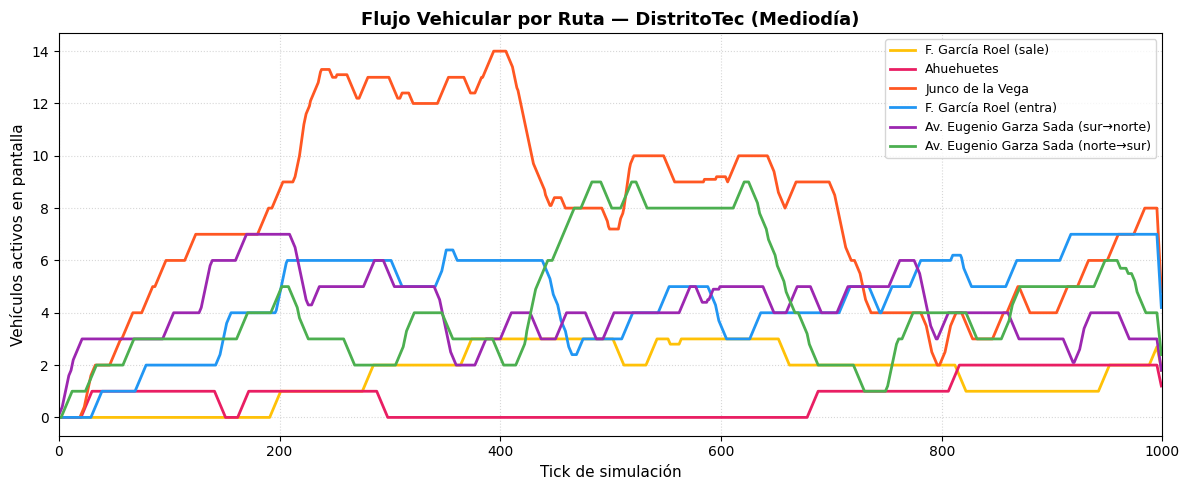

Vehículos totales generados: 115


In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))

colores_rutas = {
    'flujo_principal':        '#FFC107',
    'flujo_incorporacion':    '#E91E63',
    'flujo_avenida_vertical': '#FF5722',
    'flujo_azul_entrante':    '#2196F3',
    'flujo_sur_norte':        '#9C27B0',
    'flujo_norte_sur':        '#4CAF50',
}
nombres_rutas = {
    'flujo_principal':        'F. García Roel (sale)',
    'flujo_incorporacion':    'Ahuehuetes',
    'flujo_avenida_vertical': 'Junco de la Vega',
    'flujo_azul_entrante':    'F. García Roel (entra)',
    'flujo_sur_norte':        'Av. Eugenio Garza Sada (sur→norte)',
    'flujo_norte_sur':        'Av. Eugenio Garza Sada (norte→sur)',
}

ticks = list(range(len(list(modelo.historial_flujo.values())[0])))

for ruta, vals in modelo.historial_flujo.items():
    vals_smooth = np.convolve(vals, np.ones(10)/10, mode='same')
    ax.plot(ticks[:len(vals_smooth)], vals_smooth,
            color=colores_rutas[ruta],
            label=nombres_rutas[ruta],
            linewidth=2)

ax.set_title('Flujo Vehicular por Ruta — DistritoTec (Mediodía)',
             fontsize=13, weight='bold')
ax.set_xlabel('Tick de simulación', fontsize=11)
ax.set_ylabel('Vehículos activos en pantalla', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(0, parameters['steps'])
plt.tight_layout()
plt.show()
print(f"Vehículos totales generados: {modelo.total_creados}")

## Gráfica 2 — Longitud de Cola por Semáforo

Muestra cuántos vehículos están esperando en cada semáforo a lo largo del tiempo.
La línea sólida representa la cola de la **Fase A** y la punteada la **Fase B**.

- Colas largas indican que la heurística debe activar **EXTEND_GREEN** o **REQUEST_GREEN**.
- Colas cortas indican que el flujo es fluido y el semáforo mantiene **KEEP_GREEN**.

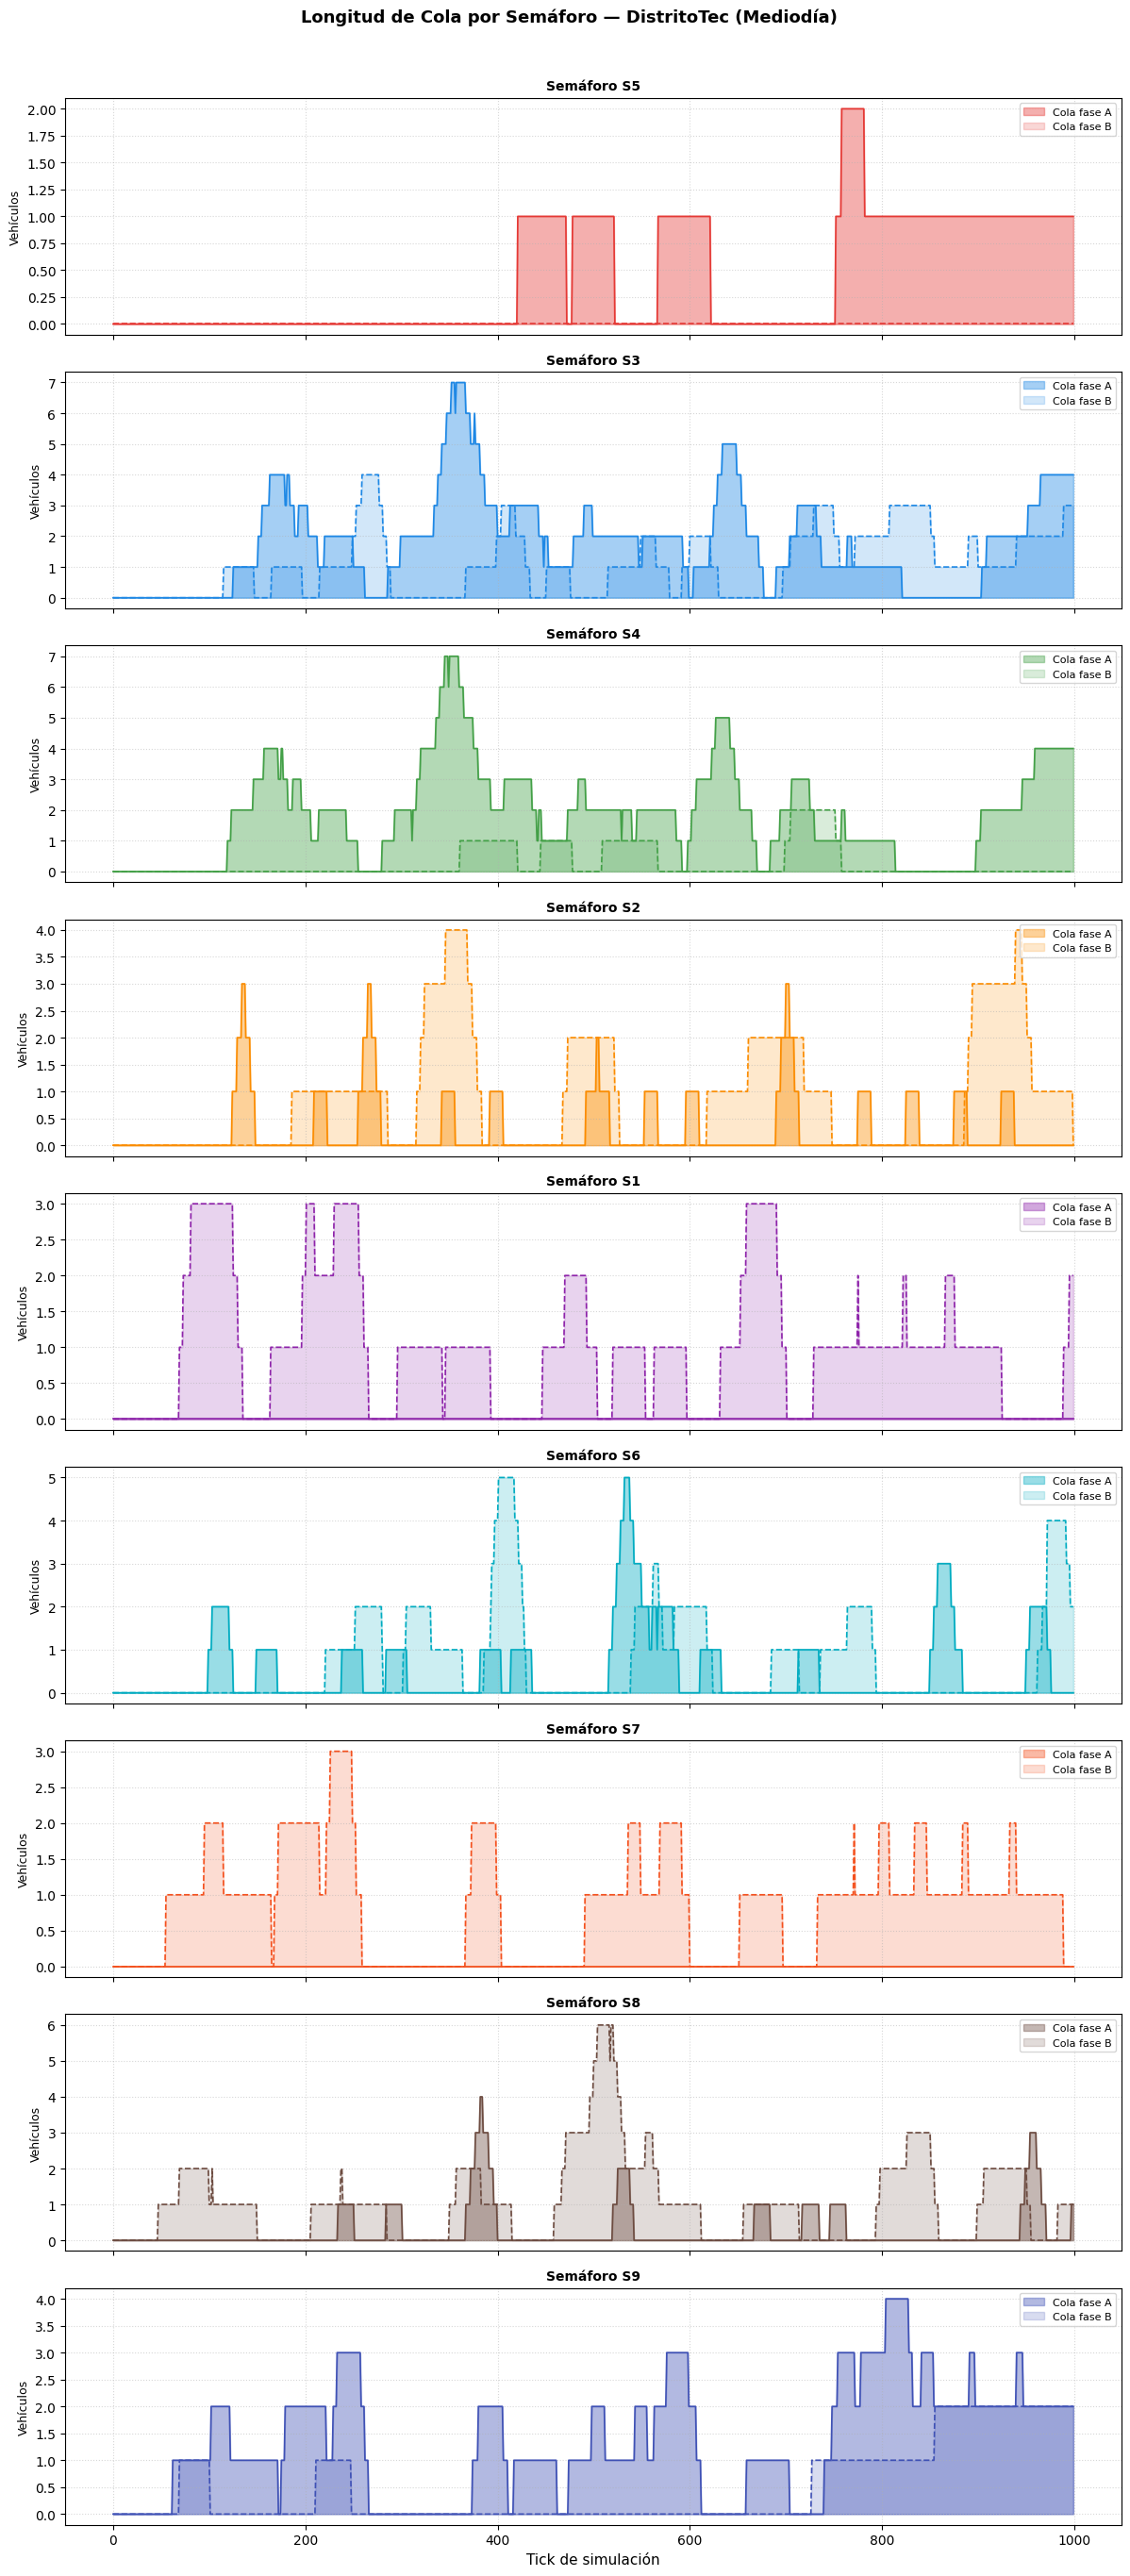

In [ ]:
fig, axes = plt.subplots(len(modelo.semaforos), 1,
                          figsize=(12, 3 * len(modelo.semaforos)),
                          sharex=True)

colores_sem = [
    '#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA',
    '#00ACC1', '#F4511E', '#6D4C41', '#3F51B5'
]

for i, sem in enumerate(modelo.semaforos):
    ax = axes[i]
    ticks    = [h['timer']  for h in sem.history]
    cola_a   = [h['cola_a'] for h in sem.history]
    cola_b   = [h['cola_b'] for h in sem.history]
    t        = list(range(len(cola_a)))

    color_index = i % len(colores_sem)
    ax.fill_between(t, cola_a, alpha=0.4, color=colores_sem[color_index], label='Cola fase A')
    ax.fill_between(t, cola_b, alpha=0.2, color=colores_sem[color_index], label='Cola fase B')
    ax.plot(t, cola_a, color=colores_sem[color_index], linewidth=1.2)
    ax.plot(t, cola_b, color=colores_sem[color_index], linewidth=1.2, linestyle='--')

    ax.set_ylabel('Vehículos', fontsize=9)
    ax.set_title(f'Semáforo {sem.nombre}', fontsize=10, weight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Tick de simulación', fontsize=11)
fig.suptitle('Longitud de Cola por Semáforo — DistritoTec (Mediodía)',
             fontsize=13, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Gráfica 3 — Decisiones Heurísticas por Semáforo

Muestra la frecuencia de cada decisión tomada por la heurística en cada semáforo:

- **KEEP_GREEN** — el flujo es normal, se mantiene la fase actual.
- **EXTEND_GREEN** — hay cola alta, se extiende el verde.
- **REQUEST_GREEN** — la fase contraria tiene cola alta y la actual está vacía, se cede el paso.
- **ROJO_TOTAL** — pausa de transición entre fases (todos en rojo).

Un sistema bien calibrado debería tener mayoría de **KEEP_GREEN** con apariciones
moderadas de **EXTEND** y **REQUEST** en función del flujo real.

/tmp/ipykernel_2972/1115521401.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(decisiones_posibles, rotation=30, ha='right', fontsize=7)
/tmp/ipykernel_2972/1115521401.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(decisiones_posibles, rotation=30, ha='right', fontsize=7)
/tmp/ipykernel_2972/1115521401.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(decisiones_posibles, rotation=30, ha='right', fontsize=7)
/tmp/ipykernel_2972/1115521401.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(decisiones_posibles, rotation=30, ha='right', fontsize=7)
/tmp/ipykernel_2972/

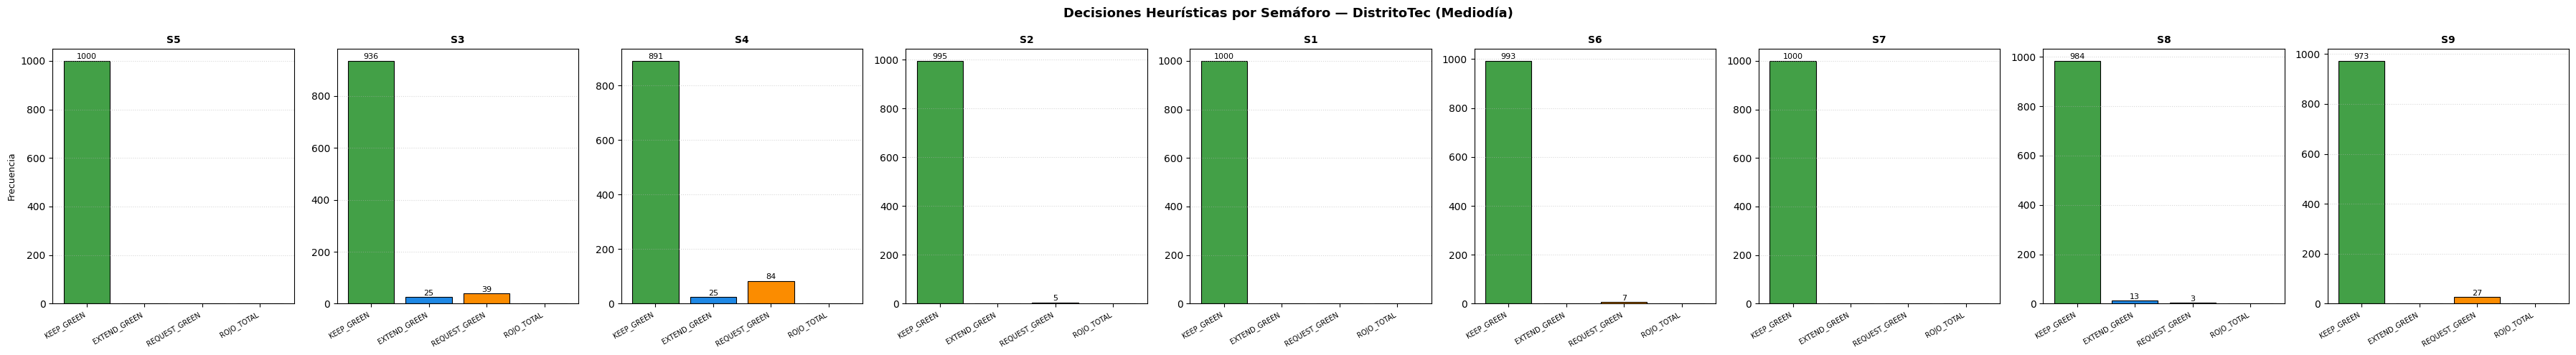


=== RESUMEN HEURÍSTICA ===

S5:
  KEEP_GREEN      1000 veces  (100.0%)
  EXTEND_GREEN       0 veces  (0.0%)
  REQUEST_GREEN      0 veces  (0.0%)
  ROJO_TOTAL         0 veces  (0.0%)

S3:
  KEEP_GREEN       936 veces  (93.6%)
  EXTEND_GREEN      25 veces  (2.5%)
  REQUEST_GREEN     39 veces  (3.9%)
  ROJO_TOTAL         0 veces  (0.0%)

S4:
  KEEP_GREEN       891 veces  (89.1%)
  EXTEND_GREEN      25 veces  (2.5%)
  REQUEST_GREEN     84 veces  (8.4%)
  ROJO_TOTAL         0 veces  (0.0%)

S2:
  KEEP_GREEN       995 veces  (99.5%)
  EXTEND_GREEN       0 veces  (0.0%)
  REQUEST_GREEN      5 veces  (0.5%)
  ROJO_TOTAL         0 veces  (0.0%)

S1:
  KEEP_GREEN      1000 veces  (100.0%)
  EXTEND_GREEN       0 veces  (0.0%)
  REQUEST_GREEN      0 veces  (0.0%)
  ROJO_TOTAL         0 veces  (0.0%)

S6:
  KEEP_GREEN       993 veces  (99.3%)
  EXTEND_GREEN       0 veces  (0.0%)
  REQUEST_GREEN      7 veces  (0.7%)
  ROJO_TOTAL         0 veces  (0.0%)

S7:
  KEEP_GREEN      1000 veces  (100.0%)
  

In [ ]:
from collections import Counter

decisiones_posibles = ['KEEP_GREEN', 'EXTEND_GREEN', 'REQUEST_GREEN', 'ROJO_TOTAL']
colores_dec = {
    'KEEP_GREEN':    '#43A047',
    'EXTEND_GREEN':  '#1E88E5',
    'REQUEST_GREEN': '#FB8C00',
    'ROJO_TOTAL':    '#E53935',
}

fig, axes = plt.subplots(1, len(modelo.semaforos),
                          figsize=(4 * len(modelo.semaforos), 5))

for i, sem in enumerate(modelo.semaforos):
    ax = axes[i]
    conteo = Counter(h['decision'] for h in sem.history)
    vals   = [conteo.get(d, 0) for d in decisiones_posibles]
    bars   = ax.bar(decisiones_posibles, vals,
                    color=[colores_dec[d] for d in decisiones_posibles],
                    edgecolor='black', linewidth=0.8)

    # Etiquetas sobre las barras
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{sem.nombre}', fontsize=10, weight='bold')
    ax.set_ylabel('Frecuencia' if i == 0 else '', fontsize=9)
    ax.set_xticklabels(decisiones_posibles, rotation=30, ha='right', fontsize=7)
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Decisiones Heurísticas por Semáforo — DistritoTec (Mediodía)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Resumen en texto
print("\n=== RESUMEN HEURÍSTICA ===")
for sem in modelo.semaforos:
    conteo = Counter(h['decision'] for h in sem.history)
    total  = len(sem.history)
    print(f"\n{sem.nombre}:")
    for d in decisiones_posibles:
        pct = conteo.get(d, 0) / total * 100 if total > 0 else 0
        print(f"  {d:<15} {conteo.get(d,0):4d} veces  ({pct:.1f}%)")

## Gráfica 4 — Fluidez Acumulada del Sistema

Muestra el porcentaje de vehículos que han completado su ruta respecto al total
que han ingresado al sistema, acumulado tick a tick.

- Una curva que sube rápido indica que los semáforos permiten un flujo eficiente.
- Una curva que se estanca indica cuellos de botella o amontonamientos.
- La línea verde punteada marca el **75% de fluidez** como referencia de buen desempeño.


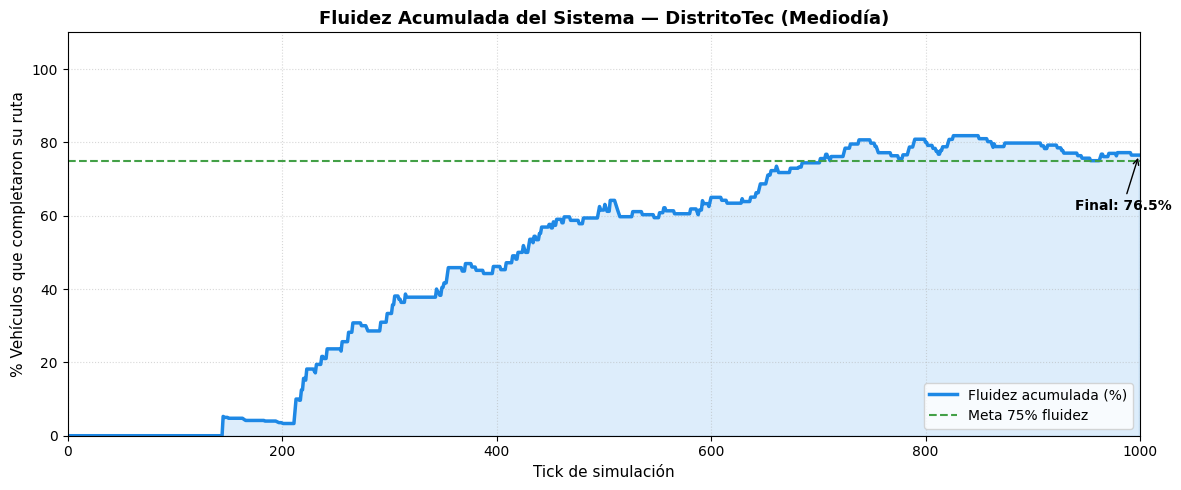


=== REPORTE FINAL ===
Vehículos ingresados:   115
Vehículos completados:  88
Fluidez final:          76.5%


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ticks = list(range(len(modelo.historial_fluidez)))

ax.plot(ticks, modelo.historial_fluidez,
        color='#1E88E5', linewidth=2.5, label='Fluidez acumulada (%)')

# Línea de referencia al 75%
ax.axhline(y=75, color='#43A047', linewidth=1.5,
           linestyle='--', label='Meta 75% fluidez')

# Zona sombreada bajo la curva
ax.fill_between(ticks, modelo.historial_fluidez,
                alpha=0.15, color='#1E88E5')

# Valor final
fluidez_final = modelo.historial_fluidez[-1] if modelo.historial_fluidez else 0
ax.annotate(f'Final: {fluidez_final:.1f}%',
            xy=(ticks[-1], fluidez_final),
            xytext=(ticks[-1] - 60, fluidez_final - 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, weight='bold')

ax.set_title('Fluidez Acumulada del Sistema — DistritoTec (Mediodía)',
             fontsize=13, weight='bold')
ax.set_xlabel('Tick de simulación', fontsize=11)
ax.set_ylabel('% Vehículos que completaron su ruta', fontsize=11)
ax.set_ylim(0, 110)
ax.set_xlim(0, parameters['steps'])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n=== REPORTE FINAL ===")
print(f"Vehículos ingresados:   {modelo.total_creados}")
print(f"Vehículos completados:  {modelo.total_cruzaron}")
print(f"Fluidez final:          {fluidez_final:.1f}%")

In [ ]:
# EXPORTACIÓN JSON PARA UNITY
import json

def exportar_json(modelo, nombre_archivo='simulacion_distritotec.json'):

    def np2list(arr):
        return [round(float(x), 3) for x in arr]

    # Waypoints de cada ruta
    waypoints = {}
    rutas = [
        'flujo_principal', 'flujo_incorporacion',
        'flujo_avenida_vertical', 'flujo_azul_entrante', 'flujo_sur_norte'
    ]
    for ruta in rutas:
        auto_temp        = Car.__new__(Car)
        auto_temp.model  = modelo
        auto_temp.space  = modelo.space
        auto_temp.route  = ruta
        auto_temp.checkpoints    = []
        auto_temp.current_cp_idx = 0
        auto_temp.esperando      = False
        auto_temp.state          = 'moving'
        auto_temp.velocity       = __import__('numpy').array([0.0, 0.0])
        auto_temp.base_speed     = 0.65
        auto_temp.build_real_tec_routes()
        waypoints[ruta] = [np2list(cp) for cp in auto_temp.checkpoints]

    # Metadatos
    metadata = {
        'size':           parameters['size'],
        'space_size':     parameters['space_size'],
        'carril':         CARRIL,
        'r_rotonda':      R_ROTONDA,
        'steps':          parameters['steps'],
        'total_creados':  modelo.total_creados,
        'total_cruzaron': modelo.total_cruzaron,
        'fluidez_pct':    round((modelo.total_cruzaron / modelo.total_creados * 100)
                                if modelo.total_creados > 0 else 0, 2)
    }

    # Cruces
    cruces = {
        'C1_rotonda':    np2list(C1),
        'C2_junco':      np2list(C2),
        'C3_ahuehuetes': np2list(C3),
        'PFA':           np2list(PFA)
    }

    # Semáforos
    semaforos_config = []
    for sem in modelo.semaforos:
        semaforos_config.append({
            'nombre':       sem.nombre,
            'pos':          np2list(sem.pos),
            'fase_a_rutas': sem.fase_a_rutas,
            'fase_b_rutas': sem.fase_b_rutas,
            'green_base':   sem.green_base,
            'green_min':    sem.green_min,
            'green_ext':    sem.green_ext
        })

    # Historial semáforos
    historial_semaforos = []
    for sem in modelo.semaforos:
        for tick, h in enumerate(sem.history):
            historial_semaforos.append({
                'tick':     tick,
                'semaforo': sem.nombre,
                'fase':     h['fase'],
                'decision': h['decision'],
                'cola_a':   h['cola_a'],
                'cola_b':   h['cola_b'],
                'timer':    h['timer']
            })

    # Historial autos — formato con wrapper para JsonUtility de Unity
    historial_autos = [
        {'autos': frame}
        for frame in modelo.historial_autos
    ]

    # JSON final
    data = {
        'metadata':            metadata,
        'cruces':              cruces,
        'waypoints':           waypoints,
        'semaforos_config':    semaforos_config,
        'historial_semaforos': historial_semaforos,
        'historial_autos':     historial_autos
    }

    with open(nombre_archivo, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

    tam = __import__('os').path.getsize(nombre_archivo) / 1024
    print("="*45)
    print("   JSON exportado correctamente")
    print("="*45)
    print(f"  Archivo:          {nombre_archivo}")
    print(f"  Tamaño:           {tam:.1f} KB")
    print(f"  Rutas exportadas: {len(waypoints)}")
    print(f"  Semáforos:        {len(semaforos_config)}")
    print(f"  Ticks guardados:  {len(historial_autos)}")
    print("="*45)


exportar_json(modelo)

   JSON exportado correctamente
  Archivo:          simulacion_distritotec.json
  Tamaño:           5023.7 KB
  Rutas exportadas: 5
  Semáforos:        9
  Ticks guardados:  1000


In [ ]:
from google.colab import files
files.download('simulacion_distritotec.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>